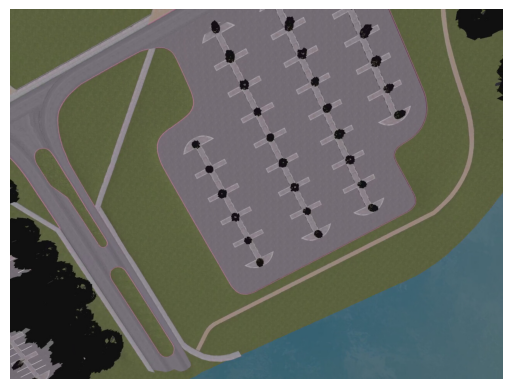

,image_file,timestamp_s,gps_lat,gps_lon,alt_agl_m,roll_deg,pitch_deg,yaw_deg,image_path
0,000000.jpg,119.546668,37.411767,-121.999277,70.066952,0.049800,-3.493300,90.003300,z:\Documents\Programs\AirTrace\map\data\Survey...
1,000001.jpg,120.046668,37.411767,-121.999261,70.039000,0.128935,-1.185365,90.039536,z:\Documents\Programs\AirTrace\map\data\Survey...
2,000002.jpg,120.546601,37.411767,-121.999244,70.012000,0.134271,-1.141784,90.090990,z:\Documents\Programs\AirTrace\map\data\Survey...
3,000003.jpg,121.046601,37.411767,-121.999232,69.993000,0.097800,-1.956800,90.045300,z:\Documents\Programs\AirTrace\map\data\Survey...
4,000004.jpg,121.546668,37.411767,-121.999222,69.982000,0.063816,-2.759711,90.003019,z:\Documents\Programs\AirTrace\map\data\Survey...


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

WORKING_DIR = os.getcwd()
DATA_DIR = os.path.join(WORKING_DIR, "data")
SURVEY_NAME = "Survey 70m"
CSV_FILE_NAME = "frames.csv"
IMAGE_FOLDER_NAME = "images"

IMG_DIR = os.path.join(DATA_DIR, SURVEY_NAME, IMAGE_FOLDER_NAME)
CSV_PATH = os.path.join(DATA_DIR, SURVEY_NAME, CSV_FILE_NAME)

def loadSurveyData(filePath):
    df = pd.read_csv(filePath)
    df["image_path"] = df["image_file"].apply(lambda x: os.path.join(IMG_DIR, x))
    return df

def displayFirstImage(df):
    firstImagePath = df.iloc[0]["image_path"]
    img = mpimg.imread(firstImagePath)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

surveyDataFrame = loadSurveyData(CSV_PATH)
displayFirstImage(surveyDataFrame)
surveyDataFrame.head()

In [6]:
N_INTERVAL = 4
ROLL_COL = "roll_deg"
PITCH_COL = "pitch_deg"

def getBestFrames(df, n):
    bestFrames = []
    
    for i in range(0, len(df), n):
        group = df.iloc[i : i + n].copy()
        group["total_rotation"] = group[ROLL_COL].abs() + group[PITCH_COL].abs()
        bestFrame = group.sort_values("total_rotation").iloc[0]
        bestFrames.append(bestFrame)
        
    return pd.DataFrame(bestFrames).reset_index(drop=True)

reducedDataFrame = getBestFrames(surveyDataFrame, N_INTERVAL)
reducedDataFrame.head()

,image_file,timestamp_s,gps_lat,gps_lon,alt_agl_m,roll_deg,pitch_deg,yaw_deg,image_path,total_rotation
0,000002.jpg,120.546601,37.411767,-121.999244,70.012000,0.134271,-1.141784,90.090990,z:\Documents\Programs\AirTrace\map\data\Survey...,1.276055
1,000004.jpg,121.546668,37.411767,-121.999222,69.982000,0.063816,-2.759711,90.003019,z:\Documents\Programs\AirTrace\map\data\Survey...,2.823527
2,000010.jpg,125.046573,37.411767,-121.999073,70.011004,0.043531,-3.068690,89.996710,z:\Documents\Programs\AirTrace\map\data\Survey...,3.112221
3,000012.jpg,126.046508,37.411767,-121.999029,70.024000,0.150099,-3.527285,90.001000,z:\Documents\Programs\AirTrace\map\data\Survey...,3.677384
4,000019.jpg,129.546585,37.411767,-121.998923,70.051000,0.101158,-2.581643,89.999584,z:\Documents\Programs\AirTrace\map\data\Survey...,2.682801


In [7]:
import cv2
import pandas as pd
import os
import glob
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
STITCH_DIR = "stitch"
FOV_DEG = 59.49
RESIZE_FACTOR = 0.9
BATCH_SIZE = 10
THRESHOLD_PERCENT = 0.05
PADDING_SIZE = 2
MAX_BRIGHTNESS = 255

LAT_COL, LON_COL = "gps_lat", "gps_lon"
ALT_COL, YAW_COL = "alt_agl_m", "yaw_deg"
ROLL_COL, PITCH_COL = "roll_deg", "pitch_deg"
PATH_COL = "image_path"

os.makedirs(STITCH_DIR, exist_ok=True)

# --- CORE FUNCTIONS ---

def cropImageBorders(img, thresholdPercent):
    grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rowsAvg = np.mean(grayImg, axis=1)
    colsAvg = np.mean(grayImg, axis=0)
    limitThreshold = MAX_BRIGHTNESS * thresholdPercent
    
    try:
        yIndices = np.where(rowsAvg > limitThreshold)[0]
        xIndices = np.where(colsAvg > limitThreshold)[0]
        
        if yIndices.size == 0 or xIndices.size == 0:
            return img
            
        yUpper, yLower = yIndices[0], yIndices[-1]
        xLeft, xRight = xIndices[0], xIndices[-1]
        
        return img[yUpper + PADDING_SIZE : yLower - PADDING_SIZE, 
                   xLeft + PADDING_SIZE : xRight - PADDING_SIZE]
    except Exception:
        return img

def processAndSaveNadir(df, outputSubdir="L0"):
    targetDir = os.path.join(STITCH_DIR, outputSubdir)
    os.makedirs(targetDir, exist_ok=True)
    
    print(f"--- STEP 1: Processing {len(df)} images to {targetDir} ---")
    
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc="Processing")):
        img = cv2.imread(row[PATH_COL])
        if img is None: continue
            
        imgRes = cv2.resize(img, (0, 0), fx=RESIZE_FACTOR, fy=RESIZE_FACTOR)
        h, w = imgRes.shape[:2]
        
        f = (w / 2) / math.tan(math.radians(FOV_DEG / 2))
        rX, rY = math.radians(row[PITCH_COL]), math.radians(row[ROLL_COL])
        RX = np.array([[1, 0, 0], [0, math.cos(rX), -math.sin(rX)], [0, math.sin(rX), math.cos(rX)]])
        RY = np.array([[math.cos(rY), 0, math.sin(rY)], [0, 1, 0], [-math.sin(rY), 0, math.cos(rY)]])
        K = np.array([[f, 0, w/2], [0, f, h/2], [0, 0, 1]])
        H = K @ (RX @ RY) @ np.linalg.inv(K)
        imgCorr = cv2.warpPerspective(imgRes, H, (w, h))
        
        M = cv2.getRotationMatrix2D((w // 2, h // 2), -row[YAW_COL], 1.0)
        imgRot = cv2.warpAffine(imgCorr, M, (w, h))
        
        imgClean = cropImageBorders(imgRot, THRESHOLD_PERCENT)
        cv2.imwrite(os.path.join(targetDir, f"frame_{i:04d}.png"), imgClean)

def manualPyramidStitch(sourceSubdir, targetSubdir, batchSize=10):
    srcPath = os.path.join(STITCH_DIR, sourceSubdir, "*.png")
    dstPath = os.path.join(STITCH_DIR, targetSubdir)
    os.makedirs(dstPath, exist_ok=True)
    
    files = sorted(glob.glob(srcPath))
    if not files:
        return
        
    print(f"--- Merging {len(files)} files: {sourceSubdir} -> {targetSubdir} ---")
    
    # SCANS jest lepszy dla map, ale PANORAMA czasem lepiej radzi sobie z geometrią.
    # Jeśli SCANS nadal "ściska", zmień na PANORAMA.
    stitcher = cv2.Stitcher_create(cv2.Stitcher_SCANS)
    
    # Obniżony próg pewności (0.1-0.2) pomaga, gdy zdjęcia mają mało detali (np. trawa)
    stitcher.setPanoConfidenceThresh(0.35)
    
    for i in tqdm(range(0, len(files), batchSize), desc=f"L: {sourceSubdir}"):
        batchFiles = files[i : i + batchSize]
        
        if len(batchFiles) < 2:
            img = cv2.imread(batchFiles[0])
            if img is not None:
                imgClean = cropImageBorders(img, THRESHOLD_PERCENT)
                cv2.imwrite(os.path.join(dstPath, f"batch_{i//batchSize:03d}.png"), imgClean)
            continue
            
        imgs = []
        for f in batchFiles:
            img = cv2.imread(f)
            if img is not None:
                imgs.append(img)
        
        if len(imgs) < 2:
            continue

        # Próba zszycia
        status, result = stitcher.stitch(imgs)
        
        if status == cv2.Stitcher_OK:
            # Sukces - czyścimy ramki powstałe po transformacji i zapisujemy
            imgClean = cropImageBorders(result, THRESHOLD_PERCENT)
            cv2.imwrite(os.path.join(dstPath, f"batch_{i//batchSize:03d}.png"), imgClean)
        else:
            # Fallback: Zapisujemy środkowe zdjęcie z batcha jako reprezentant 
            # (środkowe zazwyczaj ma najlepszy overlap z sąsiednimi batchami)
            print(f"Batch {i//batchSize} failed (Status {status}). Saving fallback frame.")
            midIdx = len(imgs) // 2
            imgClean = cropImageBorders(imgs[midIdx], THRESHOLD_PERCENT)
            cv2.imwrite(os.path.join(dstPath, f"batch_{i//batchSize:03d}.png"), imgClean)
            
        # Opcjonalne: zwolnienie pamięci
        del imgs
        if 'result' in locals(): del result

In [8]:
import shutil

# --- CLEANUP ---
if os.path.exists(STITCH_DIR):
    print(f"Cleaning up {STITCH_DIR}...")
    shutil.rmtree(STITCH_DIR)

# Recreate the main directory
os.makedirs(STITCH_DIR, exist_ok=True)

# --- EXECUTION ---

# 1. Prepare Nadir images (L0)
processAndSaveNadir(reducedDataFrame.iloc[:100], outputSubdir="L0")

# 2. First level merge (L0 -> L1)
manualPyramidStitch(sourceSubdir="L0", targetSubdir="L1", batchSize=BATCH_SIZE)

# 3. Second level merge (L1 -> L2)
manualPyramidStitch(sourceSubdir="L1", targetSubdir="L2", batchSize=2)

# 4. Final step (L2 -> Final)
manualPyramidStitch(sourceSubdir="L2", targetSubdir="Final", batchSize=BATCH_SIZE)

Cleaning up stitch...
--- STEP 1: Processing 100 images to stitch\L0 ---


Processing: 100%|██████████| 100/100 [00:09<00:00, 10.62it/s]


--- Merging 100 files: L0 -> L1 ---


L: L0: 100%|██████████| 10/10 [00:20<00:00,  2.03s/it]


--- Merging 10 files: L1 -> L2 ---


L: L1:  80%|████████  | 4/5 [00:00<00:00,  5.94it/s]

Batch 3 failed (Status 1). Saving fallback frame.


L: L1: 100%|██████████| 5/5 [00:00<00:00,  5.47it/s]


--- Merging 5 files: L2 -> Final ---


L: L2: 100%|██████████| 1/1 [00:00<00:00,  3.52it/s]
